In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [24]:
df = pd.DataFrame(np.random.random_sample((100,2)),columns=['Feature1','Feature2'])

In [25]:
df.head()

,Feature1,Feature2
0,0.467486,0.377384
1,0.770270,0.163107
2,0.594802,0.728706
3,0.889100,0.879430
4,0.769271,0.888484


In [26]:
x = df['Feature1']
y = df['Feature2']

In [27]:
sc = StandardScaler()
normalized_data = sc.fit_transform(df)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

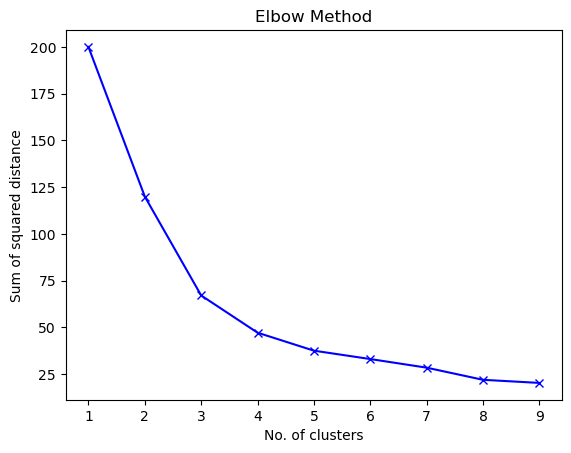

In [28]:
k = range(1,10)
ssm = []
for i in k:
    km = KMeans(n_clusters=i)
    km.fit(normalized_data)
    ssm.append(km.inertia_)
plt.plot(k,ssm,'bx-')
plt.xlabel("No. of clusters")
plt.ylabel("Sum of squared distance")
plt.title("Elbow Method")
plt.show()

In [29]:
km = KMeans(n_clusters=4)
km.fit(normalized_data)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [30]:
df['labels'] = km.labels_

In [31]:
df.head()

,Feature1,Feature2,labels
0,0.467486,0.377384,2
1,0.770270,0.163107,2
2,0.594802,0.728706,3
3,0.889100,0.879430,0
4,0.769271,0.888484,0


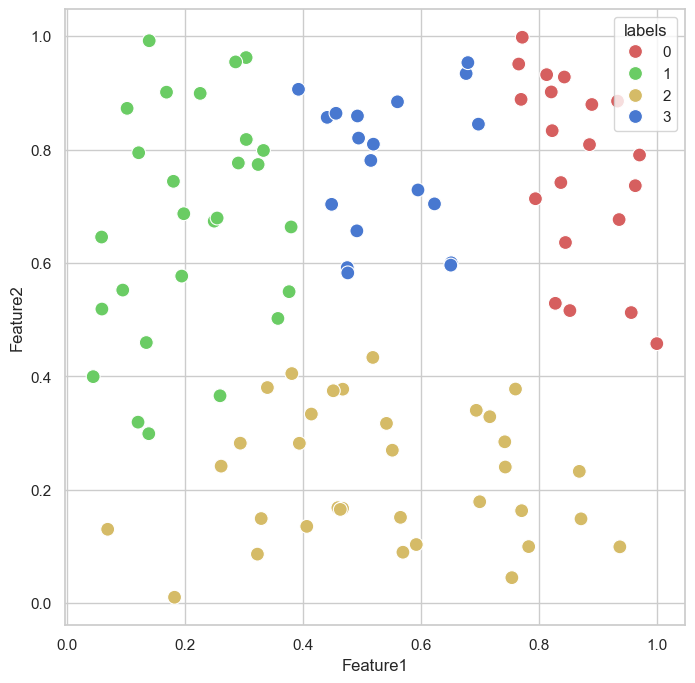

In [32]:
plt.figure(figsize=(8,8))
sns.set(style="whitegrid",palette='muted')
sns.scatterplot(x='Feature1',y='Feature2',s=100,data=df,hue='labels',palette={0:'r',1:'g',2:'y',3:'b'})
plt.show()